# Task 2: Painting Similarity Retrieval (NGA Open Data)

This notebook builds an image-similarity system for paintings using the National Gallery of Art open dataset in `../opendata-main`.

## Strategy
- Use open-access thumbnail URLs from NGA metadata as image source.
- Build visual embeddings with a pretrained CNN encoder (ResNet50).
- Use cosine similarity to retrieve nearest neighbor paintings.
- Evaluate retrieval quality with artist-based relevance labels and portrait-focused subsets.

## Why this approach
- Pretrained visual encoders provide strong generic features without expensive full training.
- Nearest-neighbor retrieval on embeddings is simple, scalable, and interpretable.
- Artist labels are a practical supervised proxy for semantic/style similarity when explicit pair labels are unavailable.

In [3]:
import os
import random
from pathlib import Path
from urllib.request import urlopen, Request

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from sklearn.metrics import average_precision_score
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


In [ ]:
DATA_DIR = Path("..") / "opendata-main" / "data"
CACHE_DIR = Path("./image_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

MAX_IMAGES = 800
MIN_IMAGES_PER_ARTIST = 3
DOWNLOAD_TIMEOUT = 15

published_images = pd.read_csv(DATA_DIR / "published_images.csv")
objects = pd.read_csv(DATA_DIR / "objects.csv", usecols=["objectid", "title", "classification", "beginyear", "endyear"])
obj_const = pd.read_csv(DATA_DIR / "objects_constituents.csv", usecols=["objectid", "constituentid", "roletype"])
constituents = pd.read_csv(DATA_DIR / "constituents.csv", usecols=["constituentid", "preferreddisplayname", "artistofngaobject"])
terms = pd.read_csv(DATA_DIR / "objects_terms.csv", usecols=["objectid", "termtype", "term"])

# Keep primary open-access views tied to objects.
img_df = published_images.copy()
img_df["objectid"] = pd.to_numeric(img_df["depictstmsobjectid"], errors="coerce")
img_df = img_df[img_df["viewtype"].fillna("").str.lower() == "primary"]
img_df = img_df.dropna(subset=["objectid", "iiifthumburl"]).copy()
img_df["objectid"] = img_df["objectid"].astype(int)

# Artist mapping using roletype=artist.
artist_links = obj_const[obj_const["roletype"].fillna("").str.lower() == "artist"].copy()
artist_links = artist_links.merge(constituents, on="constituentid", how="left")
artist_links = artist_links[["objectid", "constituentid", "preferreddisplayname"]].dropna(subset=["preferreddisplayname"])
artist_links = artist_links.rename(columns={"preferreddisplayname": "artist_name", "constituentid": "artist_id"})

meta = img_df.merge(objects, on="objectid", how="left")
meta = meta.merge(artist_links, on="objectid", how="inner")

# Portrait flag from terms and titles.
portrait_term_ids = set(
    terms[terms["term"].fillna("").str.lower().str.contains("portrait", regex=False)]["objectid"].astype(int).tolist()
)
meta["is_portrait"] = meta["objectid"].isin(portrait_term_ids) | meta["title"].fillna("").str.lower().str.contains("portrait")

# Keep artists with enough images for retrieval evaluation.
artist_counts = meta.groupby("artist_id")["uuid"].count().reset_index(name="n")
valid_artists = set(artist_counts[artist_counts["n"] >= MIN_IMAGES_PER_ARTIST]["artist_id"].tolist())
meta = meta[meta["artist_id"].isin(valid_artists)].copy()

# Deduplicate by image UUID and sample a manageable subset.
meta = meta.drop_duplicates(subset=["uuid"]).sample(
    n=min(MAX_IMAGES, len(meta)),
    random_state=SEED,
).reset_index(drop=True)

print("Prepared metadata rows:", len(meta))
print("Unique artists:", meta["artist_id"].nunique())
print("Portrait share:", round(meta["is_portrait"].mean(), 3))
meta[["uuid", "objectid", "artist_name", "title", "is_portrait"]].head()

Prepared metadata rows: 800
Unique artists: 536
Portrait share: 0.078


,uuid,objectid,artist_name,title,is_portrait
0,79dc4ab8-c6a3-49f9-ac34-0360be090b93,154077,"Pissarro, Camille",A Woman Walking along a Country Road (La Femme...,False
1,776a3884-1be9-46a0-bd8e-632b7a06fa34,48261,"Jacquard, Antoine",Apollo and Daphne,False
2,4b182bb5-6e61-4d4a-820f-20dc862990ac,197313,"Birch, William Russell","High Street, from Ninth Street, Philadelphia",False
3,4b393c85-3cc8-428d-b3fc-bffe95607a12,148836,"Fulwider, Edwin L.",The Senator Arrives,False
4,781a4822-5162-448c-8985-7ca295b32e91,16281,American 20th Century,Armchair,False


In [5]:
def download_thumbnail(url: str, dst_path: Path, timeout: int = 15):
    if dst_path.exists():
        return True
    try:
        req = Request(url, headers={"User-Agent": "Mozilla/5.0"})
        with urlopen(req, timeout=timeout) as resp:
            dst_path.write_bytes(resp.read())
        return True
    except Exception:
        return False


local_paths = []
ok_flags = []
for _, row in tqdm(meta.iterrows(), total=len(meta), desc="Caching thumbnails"):
    dst = CACHE_DIR / f"{row['uuid']}.jpg"
    ok = download_thumbnail(row["iiifthumburl"], dst, timeout=DOWNLOAD_TIMEOUT)
    local_paths.append(str(dst))
    ok_flags.append(ok)

meta["local_path"] = local_paths
meta["download_ok"] = ok_flags
meta = meta[meta["download_ok"]].reset_index(drop=True)

print("Downloaded/available images:", len(meta))
if len(meta) < 50:
    raise RuntimeError("Too few images available for retrieval. Check internet/network access.")

Caching thumbnails: 100%|██████████| 800/800 [25:23<00:00,  1.90s/it]

Downloaded/available images: 800


In [6]:
transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class ImagePathDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), idx


dataset = ImagePathDataset(meta["local_path"].tolist(), transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)

# Pretrained encoder for embeddings.
weights = models.ResNet50_Weights.IMAGENET1K_V2
resnet = models.resnet50(weights=weights)
encoder = nn.Sequential(*list(resnet.children())[:-1]).to(device).eval()

embeddings = np.zeros((len(meta), 2048), dtype=np.float32)
with torch.no_grad():
    for images, idxs in tqdm(loader, desc="Embedding images"):
        images = images.to(device)
        feats = encoder(images).flatten(1).cpu().numpy()
        embeddings[idxs.numpy()] = feats

# L2-normalize for cosine similarity via dot product.
norms = np.linalg.norm(embeddings, axis=1, keepdims=True) + 1e-12
embeddings = embeddings / norms
print("Embedding shape:", embeddings.shape)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/kalamay/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:11<00:00, 8.66MB/s]
Embedding images: 100%|██████████| 25/25 [01:25<00:00,  3.42s/it]

Embedding shape: (800, 2048)


In [7]:
def get_ranked_indices(query_idx, emb_matrix):
    sims = emb_matrix @ emb_matrix[query_idx]
    ranked = np.argsort(-sims)
    ranked = ranked[ranked != query_idx]
    return ranked, sims


def retrieval_metrics(emb_matrix, labels, query_indices, ks=(1, 5, 10)):
    recalls = {k: [] for k in ks}
    aps = []
    ndcgs = []

    for q in query_indices:
        ranked, sims = get_ranked_indices(q, emb_matrix)
        rel = (labels[ranked] == labels[q]).astype(np.int32)

        # Recall@K: was at least one relevant item found in top K?
        for k in ks:
            recalls[k].append(float(rel[:k].sum() > 0))

        # AP and nDCG use full ranking relevance vector.
        y_true = rel
        y_score = sims[ranked]
        if y_true.sum() > 0:
            aps.append(average_precision_score(y_true, y_score))
        else:
            aps.append(0.0)

        gains = y_true
        discounts = 1.0 / np.log2(np.arange(2, len(gains) + 2))
        dcg = float((gains * discounts).sum())
        ideal = np.sort(y_true)[::-1]
        idcg = float((ideal * discounts).sum()) + 1e-12
        ndcgs.append(dcg / idcg)

    out = {f"Recall@{k}": float(np.mean(v)) for k, v in recalls.items()}
    out["mAP"] = float(np.mean(aps))
    out["nDCG"] = float(np.mean(ndcgs))
    return out

labels_artist = meta["artist_id"].to_numpy()
query_pool = np.arange(len(meta))

# Use a fixed subset of queries for faster evaluation.
n_queries = min(200, len(query_pool))
query_indices = np.random.RandomState(SEED).choice(query_pool, size=n_queries, replace=False)

metrics_all = retrieval_metrics(embeddings, labels_artist, query_indices, ks=(1, 5, 10))
print("Artist-based retrieval metrics (all paintings):")
for k, v in metrics_all.items():
    print(f"{k}: {v:.4f}")

portrait_mask = meta["is_portrait"].to_numpy().astype(bool)
portrait_indices = np.where(portrait_mask)[0]
if len(portrait_indices) >= 20:
    p_queries = np.random.RandomState(SEED).choice(
        portrait_indices,
        size=min(100, len(portrait_indices)),
        replace=False,
    )
    metrics_portrait = retrieval_metrics(embeddings, labels_artist, p_queries, ks=(1, 5, 10))
    print("\nArtist-based retrieval metrics (portrait subset):")
    for k, v in metrics_portrait.items():
        print(f"{k}: {v:.4f}")
else:
    metrics_portrait = None
    print("\nPortrait subset too small for stable metrics.")

Artist-based retrieval metrics (all paintings):
Recall@1: 0.1050
Recall@5: 0.1750
Recall@10: 0.2200
mAP: 0.0934
nDCG: 0.1781

Artist-based retrieval metrics (portrait subset):
Recall@1: 0.2097
Recall@5: 0.2903
Recall@10: 0.3710
mAP: 0.2015
nDCG: 0.2927


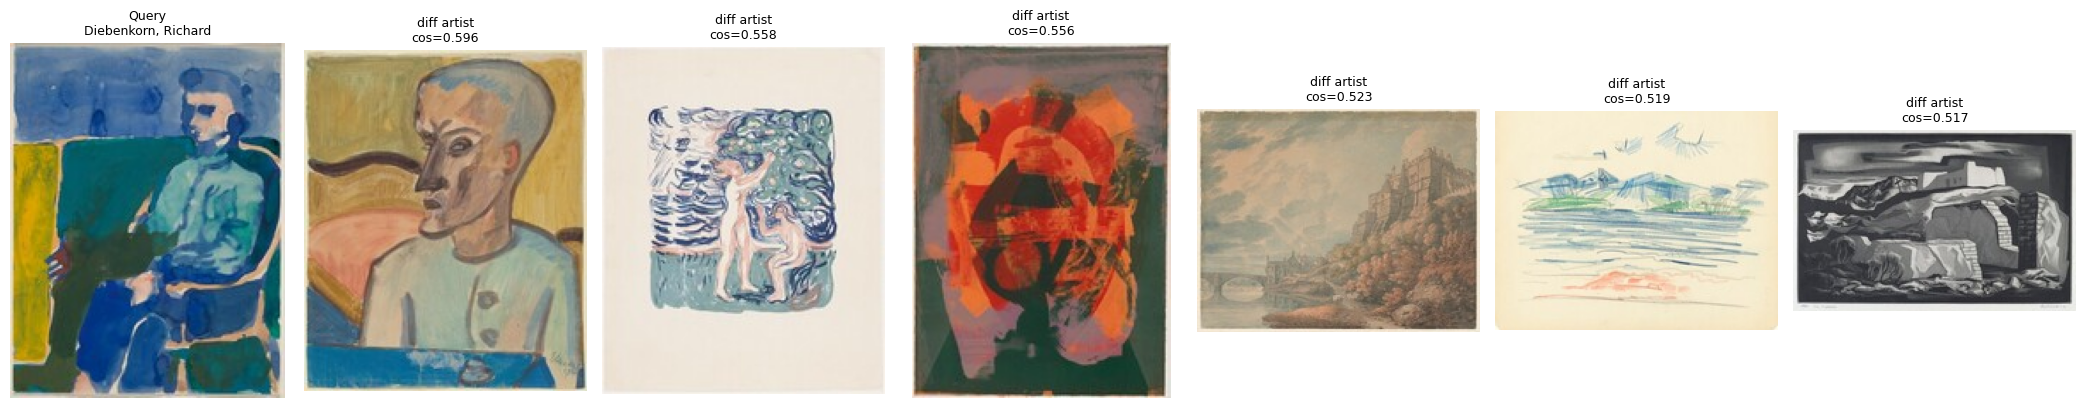

In [8]:
def show_topk_similar(query_idx, emb_matrix, meta_df, k=6):
    ranked, sims = get_ranked_indices(query_idx, emb_matrix)
    topk = ranked[:k]

    fig, axes = plt.subplots(1, k + 1, figsize=(3 * (k + 1), 4))

    qimg = Image.open(meta_df.loc[query_idx, "local_path"]).convert("RGB")
    axes[0].imshow(qimg)
    axes[0].set_title(
        "Query\n" + str(meta_df.loc[query_idx, "artist_name"])[:40],
        fontsize=9,
    )
    axes[0].axis("off")

    for i, idx in enumerate(topk, start=1):
        img = Image.open(meta_df.loc[idx, "local_path"]).convert("RGB")
        axes[i].imshow(img)
        same_artist = meta_df.loc[idx, "artist_id"] == meta_df.loc[query_idx, "artist_id"]
        tag = "same artist" if same_artist else "diff artist"
        axes[i].set_title(f"{tag}\ncos={sims[idx]:.3f}", fontsize=9)
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# Visual examples: one random portrait query if available, otherwise any random query.
if len(portrait_indices) > 0:
    q = int(np.random.choice(portrait_indices, 1)[0])
else:
    q = int(np.random.choice(np.arange(len(meta)), 1)[0])

show_topk_similar(q, embeddings, meta, k=6)

## Metric discussion (for report)

This notebook evaluates similarity retrieval with ranking metrics:

- Recall@K: fraction of queries where at least one relevant image appears in the top-K results.
- mAP (mean Average Precision): rewards methods that rank many relevant images early.
- nDCG: position-aware ranking quality relative to the ideal ranking.

Relevance definition used here: images are relevant if they share the same artist as the query. This is a practical proxy for stylistic/semantic similarity when explicit human similarity labels are unavailable.

For portrait-focused analysis, the same metrics are also computed on a portrait-only query subset (identified via `objects_terms` and title matching).